# 3.1 — Conservative Oversampling on Resplit Data

Apply **conservative oversampling** (3× no-helmet, 2× no-vest) on the **resplit dataset**
(70:15:15 stratified split from notebook 3.0) and train YOLOv8s.

**Changes from 2.2:**
- Data is resplit from scratch (no original train/val/test split)
- Same oversampling strategy (3×/2×, no copy_paste)

## Setup

In [1]:
# @title Install dependencies
!pip install -q ultralytics roboflow loguru typer python-dotenv pyyaml matplotlib opencv-python-headless albumentations

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.0/250.0 kB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 148.9 MB/s eta 0:00:00


In [2]:
# @title Mount Drive or clone repo
import os
from pathlib import Path
import sys

!git clone https://github.com/Hndra04/AlGear
PROJECT_DIR = Path("/content/AlGear")

os.chdir(str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR))
print(f"Project root: {PROJECT_DIR}")

Cloning into 'AlGear'...
remote: Enumerating objects: 130, done.
remote: Counting objects: 100% (2/2), done.
remote: Total 130 (delta 1), reused 1 (delta 1), pack-reused 128 (from 1)
Receiving objects: 100% (130/130), 63.15 MiB | 11.89 MiB/s, done.
Resolving deltas: 100% (60/60), done.
Project root: /content/AlGear


In [ ]:
# @title Set Roboflow API key
import os
os.environ["ROBOFLOW_API_KEY"] = ""

from algear.config import ROBOFLOW_DIR, ROBOFLOW_API_KEY
print(f"API key set: {bool(ROBOFLOW_API_KEY)}")
print(f"Dataset at: {ROBOFLOW_DIR}")

2026-06-23 01:32:44.368 | INFO     | algear.config:<module>:10 - PROJ_ROOT path is: /content/AlGear


API key set: True
Dataset at: /content/AlGear/data/raw/construction-safety-gsnvb


In [4]:
# @title Download dataset (if not already present)
if not ROBOFLOW_DIR.exists():
    from algear.dataset import download_roboflow
    download_roboflow(output_dir=ROBOFLOW_DIR)
else:
    print(f"Dataset already exists at {ROBOFLOW_DIR}")

2026-06-23 01:32:44.714 | INFO     | algear.dataset:download_roboflow:35 - Downloading roboflow-100/construction-safety-gsnvb v1 to /content/AlGear/data/raw/construction-safety-gsnvb
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/AlGear/data/raw/construction-safety-gsnvb in yolov8:: 100%|██████████| 2424/2424 [00:00<00:00, 4944.81it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
2026-06-23 01:33:16.514 | SUCCESS  | algear.dataset:download_roboflow:39 - Dataset downloaded to /content/AlGear/data/raw/construction-safety-gsnvb


## 1. Resplit Dataset (70:15:15)

If the resplit dataset doesn't exist yet, run notebook 3.0 first.

In [5]:
# @title Resplit dataset (skip if already done)
from algear.dataset import resplit

RESPLIT_DIR = PROJECT_DIR / "data" / "processed" / "construction-site-safety-resplit"

if not (RESPLIT_DIR / "data.yaml").exists():
    print("Running resplit...")
    resplit(
        src_dir=ROBOFLOW_DIR,
        output_dir=RESPLIT_DIR,
        train_ratio=0.70,
        val_ratio=0.15,
        test_ratio=0.15,
        seed=42,
    )
else:
    print(f"Resplit dataset already exists at {RESPLIT_DIR}")

Running resplit...
2026-06-23 01:33:16.524 | INFO     | algear.dataset:resplit:154 - Collecting image-label pairs from all splits...
2026-06-23 01:33:16.789 | INFO     | algear.dataset:resplit:182 - Total unique pairs: 1206, duplicates skipped: 0
2026-06-23 01:33:16.817 | INFO     | algear.dataset:resplit:197 - Unique class signatures: 19
2026-06-23 01:33:16.817 | DEBUG    | algear.dataset:resplit:200 -     517 images — ['helmet', 'person', 'vest']
2026-06-23 01:33:16.817 | DEBUG    | algear.dataset:resplit:200 -     368 images — ['helmet', 'no-vest', 'person']
2026-06-23 01:33:16.817 | DEBUG    | algear.dataset:resplit:200 -     127 images — ['helmet', 'person']
2026-06-23 01:33:16.817 | DEBUG    | algear.dataset:resplit:200 -      59 images — ['helmet', 'no-vest', 'person', 'vest']
2026-06-23 01:33:16.817 | DEBUG    | algear.dataset:resplit:200 -      29 images — ['person']
2026-06-23 01:33:16.817 | DEBUG    | algear.dataset:resplit:200 -      21 images — ['helmet', 'no-helmet', 'no-

## 2. Class Distribution (Resplit Train Set)

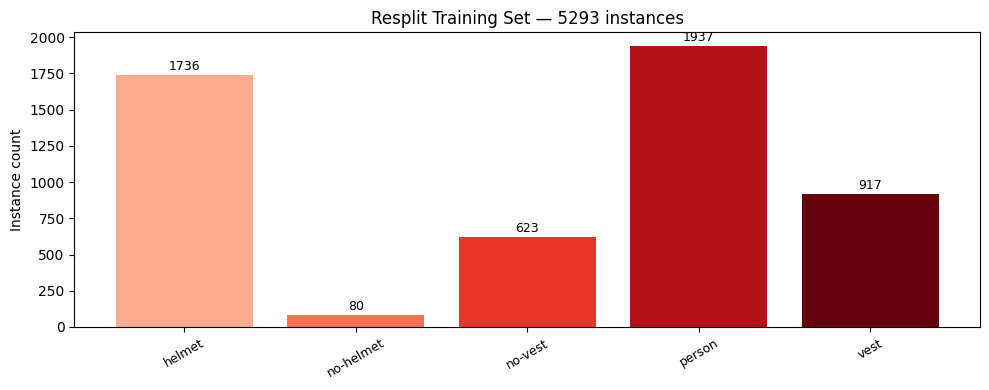

Imbalance ratio (helmet:no-helmet):  21.7x
Imbalance ratio (vest:no-vest):      1.5x


In [6]:
# @title Visualise resplit train class distribution
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import yaml

with open(RESPLIT_DIR / "data.yaml") as f:
    data_cfg = yaml.safe_load(f)
class_names = data_cfg["names"]
num_classes = len(class_names)

def count_instances(lbl_dir) -> Counter:
    c = Counter()
    for lbl in lbl_dir.glob("*.txt"):
        with open(lbl) as f:
            for line in f:
                c[int(line.strip().split()[0])] += 1
    return c

train_counts = count_instances(RESPLIT_DIR / "train" / "labels")
total = sum(train_counts.values())

fig, ax = plt.subplots(figsize=(10, 4))
names = [class_names[i] for i in range(num_classes)]
counts = [train_counts.get(i, 0) for i in range(num_classes)]
colors = plt.cm.Reds(np.linspace(0.3, 1.0, num_classes))

bars = ax.bar(names, counts, color=colors)
ax.set_title(f"Resplit Training Set — {total} instances")
ax.set_ylabel("Instance count")
ax.tick_params(axis="x", rotation=30, labelsize=9)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            str(c), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Imbalance ratio (helmet:no-helmet):  {counts[0] / max(counts[1], 1):.1f}x")
print(f"Imbalance ratio (vest:no-vest):      {counts[4] / max(counts[2], 1):.1f}x")

## 3. Oversample (Conservative: 3× no-helmet, 2× no-vest)

In [7]:
# @title Run conservative oversampling on resplit train set
from algear.dataset import oversample

OVERSAMPLED_DIR = PROJECT_DIR / "data" / "processed" / "resplit-oversampled"

oversample(
    labels_dir=RESPLIT_DIR / "train" / "labels",
    img_dir=RESPLIT_DIR / "train" / "images",
    output_dir=OVERSAMPLED_DIR,
    multiplier_no_helmet=3,
    multiplier_no_vest=2,
)

2026-06-23 01:33:17.466 | INFO     | algear.dataset:oversample:87 - Class 1 (no-helmet): 43 images, multiplier=3, ~86 augmented copies
2026-06-23 01:33:17.466 | INFO     | algear.dataset:oversample:87 - Class 2 (no-vest): 326 images, multiplier=2, ~326 augmented copies
2026-06-23 01:33:17.466 | INFO     | algear.dataset:oversample:93 - Creating oversampled dataset in /content/AlGear/data/processed/resplit-oversampled


Oversampling: 100%|██████████| 834/834 [00:08<00:00, 103.24files/s]

2026-06-23 01:33:27.054 | INFO     | algear.modeling.oversample:create_oversampled_dataset:116 - Oversampling complete: 834 originals + 387 augmented = 1221 total
2026-06-23 01:33:27.057 | SUCCESS  | algear.dataset:oversample:114 - Oversampled dataset ready at /content/AlGear/data/processed/resplit-oversampled


## 4. Class Distribution After Oversampling

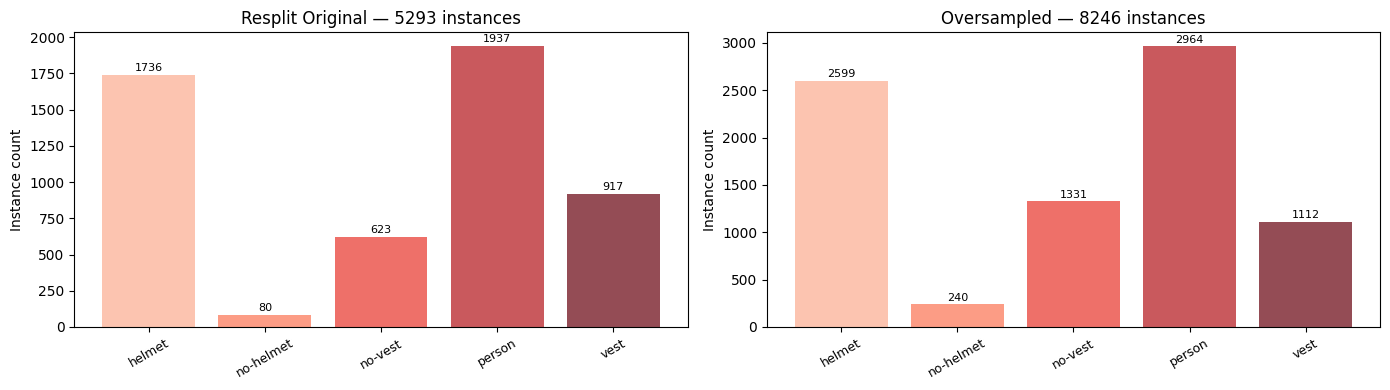

Imbalance ratio (helmet:no-helmet):  10.8x
Imbalance ratio (vest:no-vest):      0.8x


In [8]:
# @title Visualise oversampled class distribution
os_counts = count_instances(OVERSAMPLED_DIR / "train" / "labels")
os_total = sum(os_counts.values())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
os_counts_list = [os_counts.get(i, 0) for i in range(num_classes)]

ax1.bar(names, counts, color=colors, alpha=0.7)
ax1.set_title(f"Resplit Original — {total} instances")
ax1.set_ylabel("Instance count")
ax1.tick_params(axis="x", rotation=30, labelsize=9)

ax2.bar(names, os_counts_list, color=colors, alpha=0.7)
ax2.set_title(f"Oversampled — {os_total} instances")
ax2.set_ylabel("Instance count")
ax2.tick_params(axis="x", rotation=30, labelsize=9)

for ax, cts in [(ax1, counts), (ax2, os_counts_list)]:
    for bar, c in zip(ax.containers[0], cts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                str(c), ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

print(f"Imbalance ratio (helmet:no-helmet):  {os_counts_list[0] / max(os_counts_list[1], 1):.1f}x")
print(f"Imbalance ratio (vest:no-vest):      {os_counts_list[4] / max(os_counts_list[2], 1):.1f}x")

## 5. Train YOLOv8s

- Oversampled train set + resplit val set (for validation)
- No `copy_paste`
- Only YOLOv8 default augmentations (mosaic, flip, HSV, scale, translate)

In [9]:
# @title Train YOLOv8s on resplit + oversampled data
import torch

device = 0 if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

from algear.modeling.train import train_yolov8

# Write a data.yaml that points to oversampled train + resplit val
import yaml
train_data_yaml = {
    "path": str(OVERSAMPLED_DIR.resolve()),
    "train": str((OVERSAMPLED_DIR / "train" / "images").resolve()),
    "val": str((RESPLIT_DIR / "val" / "images").resolve()),
    "nc": num_classes,
    "names": class_names,
}
train_yaml_path = OVERSAMPLED_DIR / "data.yaml"
with open(train_yaml_path, "w") as f:
    yaml.dump(train_data_yaml, f, default_flow_style=False)

results = train_yolov8(
    data_yaml=train_yaml_path,
    model_name="yolov8s.pt",
    name="resplit-oversample-conservative",
    epochs=50,
    imgsz=640,
    batch=16,
    device=device,
    output_dir=PROJECT_DIR / "models",
    oversample_data=False,
    copy_paste=0.0,
)

Using device: 0
GPU: Tesla T4
2026-06-23 01:33:33.480 | INFO     | algear.modeling.train:train_yolov8:46 - Training YOLOv8s on /content/AlGear/data/processed/resplit-oversampled/data.yaml
2026-06-23 01:33:33.481 | INFO     | algear.modeling.train:train_yolov8:47 - Epochs=50, imgsz=640, batch=16, device=0
2026-06-23 01:33:33.481 | INFO     | algear.modeling.train:train_yolov8:59 - NOTE: No class imbalance handling — raw training.
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/AlGear/data/processed/resplit-oversampled/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50

## 6. Evaluate on Test Set

In [10]:
# @title Evaluate best model on resplit test set
from algear.modeling.train import evaluate

best_model = PROJECT_DIR / "models" / "resplit-oversample-conservative" / "weights" / "best.pt"
print(f"Evaluating: {best_model}")

metrics = evaluate(
    model_path=best_model,
    data_yaml=RESPLIT_DIR / "data.yaml",
    split="test",
    device=device,
)

Evaluating: /content/AlGear/models/resplit-oversample-conservative/weights/best.pt
2026-06-23 01:50:27.880 | INFO     | algear.modeling.train:evaluate:106 - Evaluating /content/AlGear/models/resplit-oversample-conservative/weights/best.pt on test split
Ultralytics 8.4.75 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,519 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 23.1±14.9 MB/s, size: 74.9 KB)
val: Scanning /content/AlGear/data/processed/construction-site-safety-resplit/test/labels... 198 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 198/198 501.1it/s 0.4s
val: New cache created: /content/AlGear/data/processed/construction-site-safety-resplit/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 13/13 2.8it/s 4.7s
                   all        198       1331       0.68      0.847       0.81      0.434
       

## 7. Results Summary

| Class | 2.2 Conservative | 3.1 Resplit+Conservative |
|---|---|---|
| helmet | 0.928 | 0.932 |
| no-helmet | 0.483 | 0.660 |
| no-vest | 0.689 | 0.663 |
| person | 0.870 | 0.928 |
| vest | 0.839 |  0.865 |
| **Overall** | **0.762** | **0.810** |

In [11]:
from google.colab import files
files.download(str(PROJECT_DIR / "models" / "resplit-oversample-conservative" / "weights" / "best.pt"))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>